# Python from Zero for Materials Science
## Introductory theoretical lecture — instructor notebook

**Duration:** approximately 2 hours  
**Audience:** Materials Science PhD students, mixed level, including complete beginners  
**Format:** front-of-class / remote lecture with live demonstration

---

### Main message

Python is not the goal.  
Python is a tool to transform raw experimental or computational data into reproducible scientific results.

```text
raw data → read file → inspect/clean → calculate → plot → save → interpret
```

> **Instructor note:** This notebook is intentionally not a student exercise notebook. It is a guided demonstration notebook. The goal is to give students a mental map before the hands-on sessions.

## 0. Lecture roadmap

**By the end of this lecture, students should understand:**

1. why Python is useful for materials science;
2. what a scientific Python workflow looks like;
3. what Jupyter notebooks are;
4. the basic building blocks of Python: variables, data types, lists, `if`, loops, and functions;
5. why we will use NumPy, pandas, and matplotlib;
6. what they will be able to do by the end of the course.

> **Instructor note:** Repeat several times that students do not need to understand every line immediately. The first lecture is a map; the hands-on sessions will build the skills.

# 1. Why Python for Scientific Data Analysis?

Scientific research produces data from many sources:

- experimental instruments;
- numerical simulations;
- image analysis;
- sensors and monitoring systems;
- repeated measurements;
- literature or database collections;
- manual laboratory measurements;
- comparison between different samples, treatments, or conditions.

A common manual workflow is:

```text
instrument output → spreadsheet → manual calculations → figure → report
```

That can work for small tasks, but it becomes fragile when the dataset grows, when the analysis must be repeated, or when someone else needs to understand what was done.

Python helps make the workflow more:

- **automatic**;
- **transparent**;
- **repeatable**;
- **shareable**.

> **Speaker text:** In this course, we are not learning Python just to “learn programming”. We are learning Python because it can help us analyze scientific data in a better way.

# 2. The scientific workflow we will use

In this lecture, we will use one guiding example:

## Tensile test data

A tensile test is a mechanical test in which a sample is pulled until it deforms and, eventually, breaks.  
During the test, the instrument records how much force is applied and how much the sample elongates.

The raw data usually do not directly contain the quantities we want to discuss scientifically.  
For example, the machine may record **force** and **displacement**, but we often want to analyse **stress** and **strain**.

## Raw columns in our example dataset

- `sample_id`  
  Identifier of the sample, for example `"S01"` or `"S02"`.  
  It tells us which measurements belong to the same specimen.

- `treatment`  
  Processing condition or sample group, for example `"annealed"`, `"quenched"`, or `"as_cast"`.  
  It allows us to compare different material conditions.

- `diameter_mm`  
  Initial diameter of the cylindrical sample, measured in millimetres.  
  We use it to calculate the cross-sectional area.

- `gauge_length_mm`  
  Initial gauge length of the sample, measured in millimetres.  
  This is the reference length used to calculate strain.

- `force_N`  
  Force applied during the test, measured in newtons.  
  This is a direct output from the testing machine.

- `displacement_mm`  
  Elongation measured during the test, in millimetres.  
  This tells us how much the sample has stretched.

## Quantities we can calculate

- `area_mm2`  
  Initial cross-sectional area of the sample.  
  For a cylindrical specimen, this can be calculated from the diameter.

- `stress_MPa`  
  Stress is force divided by area.  
  It allows us to compare samples with different sizes.

- `strain`  
  Strain is displacement divided by initial gauge length.  
  It describes the relative deformation of the sample.

- `max_stress_MPa`  
  Maximum stress reached during the test.  
  This is often used as a simple indicator of strength.

- `approximate_elastic_modulus_MPa`  
  Approximate slope of the first part of the stress-strain curve.  
  This gives a rough estimate of the elastic stiffness of the material.

## Why this example is useful

This dataset is simple enough for an introductory course, but realistic enough to show a complete scientific workflow:

```text
raw measurements → calculated quantities → plot → interpretation
```

## Example of a raw CSV file

A CSV file is a plain text file where each row represents one observation and columns are separated by commas.

In this example, each row corresponds to one measurement point during a tensile test.

The same `sample_id` appears multiple times because a tensile test records many force-displacement points for the same specimen.

In [1]:
raw_csv_preview = """sample_id,treatment,diameter_mm,gauge_length_mm,force_N,displacement_mm
S01,annealed,5.00,25.00,0,0.000
S01,annealed,5.00,25.00,250,0.015
S01,annealed,5.00,25.00,500,0.030
S01,annealed,5.00,25.00,750,0.047
S01,annealed,5.00,25.00,1000,0.066
S02,quenched,5.00,25.00,0,0.000
S02,quenched,5.00,25.00,300,0.012
S02,quenched,5.00,25.00,600,0.025
S02,quenched,5.00,25.00,900,0.039
S02,quenched,5.00,25.00,1200,0.055"""

print(raw_csv_preview)

sample_id,treatment,diameter_mm,gauge_length_mm,force_N,displacement_mm
S01,annealed,5.00,25.00,0,0.000
S01,annealed,5.00,25.00,250,0.015
S01,annealed,5.00,25.00,500,0.030
S01,annealed,5.00,25.00,750,0.047
S01,annealed,5.00,25.00,1000,0.066
S02,quenched,5.00,25.00,0,0.000
S02,quenched,5.00,25.00,300,0.012
S02,quenched,5.00,25.00,600,0.025
S02,quenched,5.00,25.00,900,0.039
S02,quenched,5.00,25.00,1200,0.055


# 3. Jupyter Notebook

A notebook can contain:

- code;
- explanatory text;
- equations;
- tables;
- plots;
- outputs.

Important ideas:

- notebooks are divided into cells;
- cells can be executed one at a time;
- the order of execution matters;
- notebooks are useful for exploratory analysis;
- a good notebook should tell a reproducible story.

> **Speaker text:** A notebook is not only a place to try code. It should become a reproducible story of the analysis.

Useful reference: Jupyter describes notebooks as computational documents that combine live code, equations, narrative text, visualizations, and other output.

## Markdown cell example

This is a text cell. It is not executed as Python code.

Example notebook title:

```markdown
# Analysis of tensile test data

In this notebook, we compute stress and strain from raw force-displacement data.
```

In [2]:
print("This is a code cell example")

Hello materials science


# 4. Basic Python concepts

The basic building blocks we will introduce are:

- variables;
- data types;
- lists;
- `if` statements;
- `for` loops;
- functions.

## 4.1 Variables

A variable is a name associated with a value.

Good scientific variable names often include the physical meaning and, when useful, the unit.

Examples:

- `force_N`
- `diameter_mm`
- `stress_MPa`
- `temperature_K`
- `displacement_mm`
- `gauge_length_mm`

> **Speaker text:** A variable is just a name for something we want to use later.

In [ ]:
force_N = 1200
area_mm2 = 19.63   # cross-sectional area of a 5 mm diameter sample
stress_MPa = force_N / area_mm2

print(stress_MPa)

### Discussion point

Which version is easier to understand?

```python
x = 1200
A = 19.63
y = x / A
```

or:

```python
force_N = 1200
area_mm2 = 19.63
stress_MPa = force_N / area_mm2
```

> **Extra point for students who already program:** readable scientific code is not about clever syntax. It is about reducing ambiguity.

## 4.2 Data types

Python values can have different types.

Examples:

- text strings;
- numbers;
- booleans;
- lists.

> **Speaker text:** Different kinds of information are represented differently in Python. A number can be used in calculations; text is usually used for names or labels; a boolean is used for decisions.

In [3]:
sample_id = "S01"                      # string
force_N = 1200.0                       # number / float
is_valid = True                        # boolean
hardness_values = [220, 235, 240, 228] # list

print(type(sample_id))
print(type(force_N))
print(type(is_valid))
print(type(hardness_values))

<class 'str'>
<class 'float'>
<class 'bool'>
<class 'list'>


## 4.3 Lists

A list stores multiple values.

Examples in materials science:

- several sample names;
- several temperatures;
- several hardness measurements;
- several file names.

> **Speaker text:** A list is like a row of values stored under one name.

In [4]:
hardness_values = [220, 235, 240, 228]

print("First value:", hardness_values[0])
print("Number of values:", len(hardness_values))
print("Mean hardness:", sum(hardness_values) / len(hardness_values))

First value: 220
Number of values: 4
Mean hardness: 230.75


> **Beginner note:** In Python, counting starts from zero. The first item is at position `0`, not position `1`.

> **Extra note:** Later we will use NumPy arrays and pandas columns, which are more powerful structures for numerical and tabular data.

## 4.4 If statements

An `if` statement allows the program to make a decision.

Examples in materials science:

- if a value is above a threshold;
- if a sample belongs to a treatment group;
- if a measurement should be included or excluded;
- if stress is in an elastic or plastic region.

In [5]:
stress_MPa = 450

if stress_MPa > 400:
    print("High strength")
else:
    print("Standard strength")

High strength


> **Speaker text:** This is the same kind of reasoning we use in scientific work: if a value satisfies a criterion, we do one thing; otherwise, we do something else.

> **Extra point:** A threshold in code should have a scientific reason. Otherwise the analysis may look precise but be arbitrary.

## 4.5 For loops

A `for` loop repeats the same operation many times.

Examples in materials science:

- analyze several samples;
- process several files;
- repeat a calculation for several temperatures;
- apply the same operation to several experimental conditions.

In [6]:
samples = ["S01", "S02", "S03"]

for sample in samples:
    print("Analyzing sample", sample)

Analyzing sample S01
Analyzing sample S02
Analyzing sample S03


In [7]:
temperatures_C = [25, 100, 200, 300, 400]

for temperature_C in temperatures_C:
    temperature_K = temperature_C + 273.15
    print(temperature_C, "°C =", temperature_K, "K")

25 °C = 298.15 K
100 °C = 373.15 K
200 °C = 473.15 K
300 °C = 573.15 K
400 °C = 673.15 K


> **Speaker text:** When you see yourself repeating the same action manually, that action may be automated.

> **Extra point:** In numerical Python, we will often use vectorized operations with NumPy or pandas instead of explicit loops.

## 4.6 Functions

A function is a reusable calculation with a name.

In science, this is very natural because many calculations are based on formulas.

> **Speaker text:** A function is a named recipe: it receives inputs, does something, and returns an output.

In [ ]:
def compute_stress(force_N, area_mm2):
    return force_N / area_mm2

stress = compute_stress(1200, 19.63)
print(stress)

In [ ]:
import math


def celsius_to_kelvin(temperature_C):
    return temperature_C + 273.15


def compute_strain(displacement_mm, gauge_length_mm):
    return displacement_mm / gauge_length_mm


def compute_circular_area(diameter_mm):
    radius_mm = diameter_mm / 2
    return math.pi * radius_mm**2


print("300 °C =", celsius_to_kelvin(300), "K")
print("strain =", compute_strain(0.2, 25.0))
print("area =", compute_circular_area(5.0), "mm²")

> **Extra point:** Functions make notebooks cleaner, reduce repetition, and separate scientific logic from technical details.

# 5. Scientific Python libraries

Python gives us the language. Libraries give us specialized tools.

In this course, we will mainly use:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
```

- **NumPy**: numerical arrays and efficient numerical operations;
- **pandas**: tabular data;
- **matplotlib**: scientific plots.

## 5.1 NumPy

NumPy helps us work with many numbers efficiently.

> **Speaker text:** Instead of calculating one value at a time, we can calculate many values together.

In [10]:
import numpy as np

force_N = np.array([100, 200, 300, 400])
area_mm2 = 10

stress_MPa = force_N / area_mm2
print(stress_MPa)

[10. 20. 30. 40.]


> **Beginner note:** NumPy lets us calculate many numbers at once.

> **Extra note:** NumPy arrays are the basis of much of the scientific Python ecosystem.

## 5.2 pandas

pandas helps us work with tables.

The main object we will use is a **DataFrame**: a table with rows and columns.

With pandas, we can:

- read a CSV file;
- inspect the first rows;
- select columns;
- filter rows;
- create new columns;
- calculate summary statistics;
- group data by sample or treatment;
- save cleaned data.

In [11]:
import pandas as pd
from pathlib import Path

# Make the notebook work whether it is launched from the project root or from the notebooks folder.
if Path("data/tensile_raw.csv").exists():
    DATA_DIR = Path("data")
elif Path("../data/tensile_raw.csv").exists():
    DATA_DIR = Path("../data")
else:
    raise FileNotFoundError("Could not find the data folder. Please launch the notebook from the project root or notebooks folder.")

print("Using data folder:", DATA_DIR.resolve())

Using data folder: /mnt/data/python_materials_intro_theoretical_lecture/data


In [12]:
df = pd.read_csv(DATA_DIR / "tensile_raw.csv")
df.head()

,sample_id,treatment,diameter_mm,gauge_length_mm,force_N,displacement_mm
0,S01,annealed,5.02,25.0,0.000,0.00000
1,S01,annealed,5.02,25.0,3266.670,0.05987
2,S01,annealed,5.02,25.0,4475.874,0.11975
3,S01,annealed,5.02,25.0,4603.305,0.17962
4,S01,annealed,5.02,25.0,4572.867,0.23950


In [13]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Shape: (600, 6)
Columns: ['sample_id', 'treatment', 'diameter_mm', 'gauge_length_mm', 'force_N', 'displacement_mm']


> **Speaker text:** A DataFrame is similar to a spreadsheet, but the operations are explicit and reproducible.

## 5.3 matplotlib

matplotlib helps us create scientific plots.

A scientific plot should not be just a line. It should include:

- meaningful axis labels;
- units;
- title or legend when useful;
- readable layout.

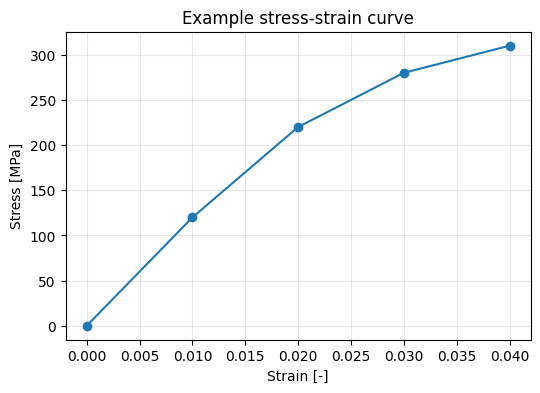

In [14]:
import matplotlib.pyplot as plt

strain = np.array([0.00, 0.01, 0.02, 0.03, 0.04])
stress_MPa = np.array([0, 120, 220, 280, 310])

plt.figure(figsize=(6, 4))
plt.plot(strain, stress_MPa, marker="o")
plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.title("Example stress-strain curve")
plt.grid(True, alpha=0.3)
plt.show()

> **Extra point:** Plotting is not only a technical step. Figure quality is part of scientific communication.

# 6. Mini demo: from raw data to a stress-strain curve

Now we combine the pieces.

Do not worry if the code looks complicated for beginners. The goal is to see the full workflow:

```text
import tools → read data → calculate new columns → select data → plot results
```

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Read the raw data file

df = pd.read_csv(DATA_DIR / "tensile_raw.csv")

# 2. Calculate cross-sectional area, stress, and strain

df["area_mm2"] = np.pi * (df["diameter_mm"] / 2) ** 2
df["stress_MPa"] = df["force_N"] / df["area_mm2"]
df["strain"] = df["displacement_mm"] / df["gauge_length_mm"]

# 3. Select one sample

sample = df[df["sample_id"] == "S01"]

# 4. Plot stress versus strain

plt.figure(figsize=(7, 4))
plt.plot(sample["strain"], sample["stress_MPa"])
plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stress-strain curve: S01")
plt.grid(True, alpha=0.3)
plt.show()

## What happened in the demo?

1. We imported tools.
2. We read a file.
3. We calculated new columns.
4. We selected one sample.
5. We created a plot.

> **Speaker text:** During the hands-on sessions, we will learn how to write and modify each part of this code ourselves.

## Optional extension for mixed-level students

For students who already know some programming, show how quickly the same workflow can be applied to multiple samples.

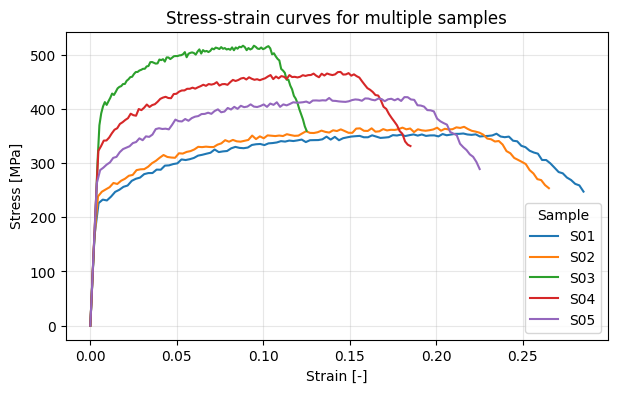

In [16]:
plt.figure(figsize=(7, 4))

for sample_id, group in df.groupby("sample_id"):
    plt.plot(group["strain"], group["stress_MPa"], label=sample_id)

plt.xlabel("Strain [-]")
plt.ylabel("Stress [MPa]")
plt.title("Stress-strain curves for multiple samples")
plt.legend(title="Sample")
plt.grid(True, alpha=0.3)
plt.show()

> **Extra point:** This is where loops and grouping become useful: the same analysis can be repeated for multiple samples without copying and pasting code.

## Optional extension: summarizing by treatment

This is not necessary for complete beginners during the first lecture, but it is useful to show the direction of the course.

In [17]:
summary = (
    df.groupby(["sample_id", "treatment"])
      .agg(
          max_stress_MPa=("stress_MPa", "max"),
          max_strain=("strain", "max")
      )
      .reset_index()
)

summary

,sample_id,treatment,max_stress_MPa,max_strain
0,S01,annealed,354.514787,0.285
1,S02,annealed,366.837551,0.265
2,S03,quenched,516.390676,0.125
3,S04,aged,468.100000,0.185
4,S05,as_received,421.590982,0.225


In [18]:
treatment_summary = (
    summary.groupby("treatment")
           .agg(
               mean_max_stress_MPa=("max_stress_MPa", "mean"),
               std_max_stress_MPa=("max_stress_MPa", "std"),
               mean_max_strain=("max_strain", "mean")
           )
           .reset_index()
)

treatment_summary

,treatment,mean_max_stress_MPa,std_max_stress_MPa,mean_max_strain
0,aged,468.100000,NaN,0.185
1,annealed,360.676169,8.713509,0.275
2,as_received,421.590982,NaN,0.225
3,quenched,516.390676,NaN,0.125


> **Speaker text:** This is the kind of output that becomes useful in research: not only a plot, but also numerical summaries that can be saved, checked, and reported.

In [19]:
output_path = DATA_DIR / "tensile_summary_by_sample.csv"
summary.to_csv(output_path, index=False)
print("Saved:", output_path)

Saved: data/tensile_summary_by_sample.csv


# 7. Errors and debugging

Errors are normal.

An error does not mean that the student is “bad at programming”. It means that Python found something inconsistent.

Common beginner errors:

- misspelled variable name;
- missing parenthesis;
- file not found;
- cell not executed;
- wrong column name;
- wrong cell execution order;
- wrong CSV separator.

> **Instructor note:** Do not run a breaking cell during a live lecture unless you want to demonstrate debugging. The cell below is safe because the error-producing line is commented out.

In [20]:
force = 100

# Uncomment the next line during the lecture if you want to demonstrate a NameError.
# print(froce)

print(force)

100


## How to explain the error if you uncomment the line

If we write:

```python
force = 100
print(froce)
```

Python raises a `NameError`, because `force` and `froce` are two different names.

> **Speaker text:** The error message may look intimidating, but it is useful. It tells us where Python got stuck and often why.

# 8. Closing

By the end of the course, students should be able to:

- read a data file;
- inspect a table;
- calculate new quantities;
- filter data;
- group data;
- create scientific plots;
- save results;
- write a clear and reproducible notebook.

We will **not** cover in depth:

- advanced software development;
- object-oriented programming;
- machine learning;
- advanced atomistic simulations;
- full XRD analysis;
- advanced image analysis;
- package development.

> **Speaker text:** The goal is not to become professional software developers. The goal is to become autonomous in everyday scientific data analysis.

# References and official documentation

Useful official references for the concepts shown in this notebook:

- Jupyter: https://jupyter.org/
- Jupyter Notebook documentation: https://jupyter-notebook.readthedocs.io/
- Python tutorial: https://docs.python.org/3/tutorial/
- Python control flow and functions: https://docs.python.org/3/tutorial/controlflow.html
- NumPy beginner guide: https://numpy.org/doc/stable/user/absolute_beginners.html
- pandas `read_csv`: https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html
- pandas I/O tools: https://pandas.pydata.org/docs/user_guide/io.html
- Matplotlib quick start: https://matplotlib.org/stable/users/explain/quick_start.html
- Matplotlib `pyplot.plot`: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html